<a href="https://colab.research.google.com/github/Amogh-S-Acharya/ML2-AMOGH_S_ACHARYA-4NI23CI012/blob/main/bnb_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'flight-delays' dataset.
Dataset downloaded to: /kaggle/input/flight-delays
Loading data...
Training shapes: (47051, 6), Testing shapes: (20165, 6)
Training Bagging Model (Random Forest)...
Training Boosting Model (Gradient Boosting)...

=== Model Performance Summary ===
                              Accuracy  Precision  Recall  ROC AUC
Bagging (Random Forest)         0.7698     0.7760  0.7554   0.8481
Boosting (Gradient Boosting)    0.8525     0.9019  0.7893   0.9136


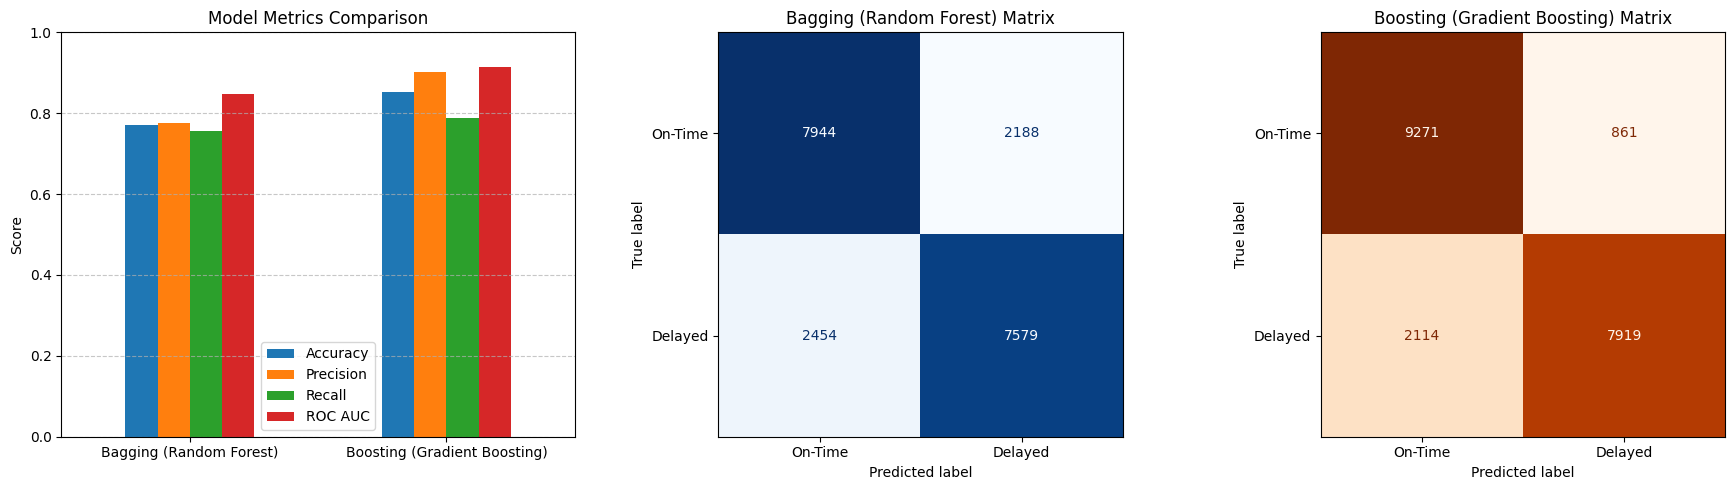

In [1]:
import os
import glob
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Download and locate the dataset
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("usdot/flight-delays")
print(f"Dataset downloaded to: {path}")

# Find flights.csv inside the downloaded directory
csv_files = glob.glob(os.path.join(path, "**", "flights.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError("Could not find flights.csv in the downloaded files.")
flights_path = csv_files[0]

# 2. Load a subset of data for fast processing (The original dataset has 5.8M rows)
print("Loading data...")
df = pd.read_csv(flights_path, nrows=100000)

# 3. Preprocessing and Feature Engineering
# Define target variable: Delayed by more than 15 minutes (1 = Delayed, 0 = On Time/Early)
df = df.dropna(subset=['ARRIVAL_DELAY'])
df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

# Select predictive tabular features
features = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DISTANCE']
X = df[features]
y = df['IS_DELAYED']

# Handle any remaining missing values
X = X.fillna(X.median())

# Downsample to create a balanced dataset for better training evaluation
delayed_indices = y[y == 1].index
ontime_indices = y[y == 0].index
random_ontime_indices = np.random.choice(ontime_indices, len(delayed_indices), replace=False)

balanced_indices = np.concatenate([delayed_indices, random_ontime_indices])
X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)
print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")

# 4. Train Bagging Model (Random Forest Classifier)
print("Training Bagging Model (Random Forest)...")
bagging_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)
y_prob_bag = bagging_model.predict_proba(X_test)[:, 1]

# 5. Train Boosting Model (Gradient Boosting Classifier)
print("Training Boosting Model (Gradient Boosting)...")
boosting_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
boosting_model.fit(X_train, y_train)
y_pred_boost = boosting_model.predict(X_test)
y_prob_boost = boosting_model.predict_proba(X_test)[:, 1]

# 6. Evaluation Metrics
metrics = {
    'Bagging (Random Forest)': {
        'Accuracy': accuracy_score(y_test, y_pred_bag),
        'Precision': precision_score(y_test, y_pred_bag),
        'Recall': recall_score(y_test, y_pred_bag),
        'ROC AUC': roc_auc_score(y_test, y_prob_bag)
    },
    'Boosting (Gradient Boosting)': {
        'Accuracy': accuracy_score(y_test, y_pred_boost),
        'Precision': precision_score(y_test, y_pred_boost),
        'Recall': recall_score(y_test, y_pred_boost),
        'ROC AUC': roc_auc_score(y_test, y_prob_boost)
    }
}

metrics_df = pd.DataFrame(metrics).T
print("\n=== Model Performance Summary ===")
print(metrics_df.round(4))

# 7. Visualization: Performance Comparison & Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Metric Comparison Chart
metrics_df.plot(kind='bar', ax=axes[0])
axes[0].set_title("Model Metrics Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_xticklabels(metrics_df.index, rotation=0)

# Plot 2: Bagging Confusion Matrix
cm_bag = confusion_matrix(y_test, y_pred_bag)
disp_bag = ConfusionMatrixDisplay(confusion_matrix=cm_bag, display_labels=['On-Time', 'Delayed'])
disp_bag.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title("Bagging (Random Forest) Matrix")

# Plot 3: Boosting Confusion Matrix
cm_boost = confusion_matrix(y_test, y_pred_boost)
disp_boost = ConfusionMatrixDisplay(confusion_matrix=cm_boost, display_labels=['On-Time', 'Delayed'])
disp_boost.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title("Boosting (Gradient Boosting) Matrix")

plt.tight_layout()
plt.show()
